## 학생 성적 영향 요인 분석(EDA)

- **데이터 분석 목적:** 학생들의 성적(Performance Index)에 영향을 미치는 주요 요인을 파악하고, 모델링을 위한 데이터 특성을 이해한다.

- **분석 데이터:**  train.csv(7,000건, 6개 변수), test.csv(3,000건, 5개 변수)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
import os

In [2]:
print("현재 작업 디렉토리:", os.getcwd())
# researcher1

현재 작업 디렉토리: d:\dev\github\mission15\researcher1


In [3]:
# 데이터 로드
train = pd.read_csv('data/mission15_train.csv')
test = pd.read_csv('data/mission15_test.csv')

### 1. 데이터 기본 특성

In [4]:
# 기본 정보 & 결측치 확인
print("=== 기본 정보 ===")
print(f"Train: {train.shape}, Test: {test.shape}")
print("\nTrain info:")
print(train.info())

=== 기본 정보 ===
Train: (7000, 6), Test: (3000, 5)

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     7000 non-null   int64  
 1   Previous Scores                   7000 non-null   int64  
 2   Extracurricular Activities        7000 non-null   object 
 3   Sleep Hours                       7000 non-null   int64  
 4   Sample Question Papers Practiced  7000 non-null   int64  
 5   Performance Index                 7000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 328.2+ KB
None


- Train/Test 비율 약 7:3으로 적절함  

- 컬럼은 범주형 1개(Extracurricular Activities), 숫자형 5개로 구성됨

### 2. 상관관계 분석

(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'Hours\nStudied'),
  Text(0, 1.5, 'Previous\nScores'),
  Text(0, 2.5, 'Sleep\nHours'),
  Text(0, 3.5, 'Sample\nQuestion\nPapers\nPracticed'),
  Text(0, 4.5, 'Performance\nIndex')])

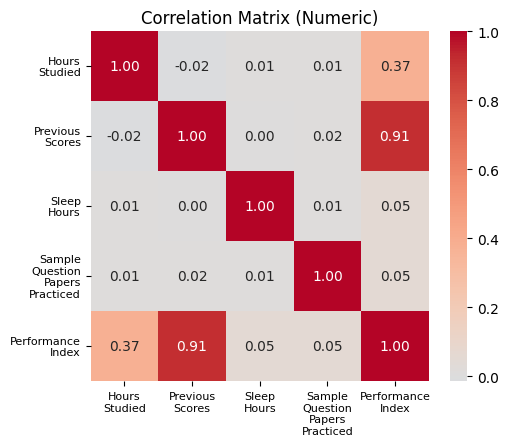

In [5]:
# 상관관계 계산(숫자형 변수만 선택)
num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']
corr_matrix = train[num_cols].corr()
labels = [c.replace(" ", "\n") for c in corr_matrix.columns]

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', xticklabels=labels, yticklabels=labels)
plt.title('Correlation Matrix (Numeric)')
plt.xticks(rotation=0, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

- Previous Scores가 성적과 0.91로 가장 강한 양의 상관관계

- Hours Studied(0.37), **Sample Question Papers(0.05)** 도 긍정적 영향

- Sleep Hours는 성적과 거의 상관없음(0.05)이나 다른 변수와도 약한 관계

- 다중공선성 없음: 숫자형 변수 간 상관관계도 낮음(최대 0.02 수준)

### 3. 타겟 변수 분포

Text(0.5, 1.0, 'Performance Index Distribution')

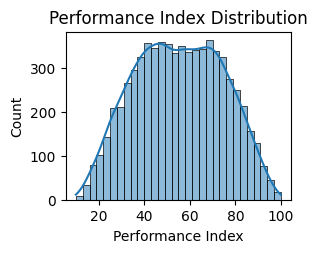

In [6]:
# 타겟 분포
plt.subplot(2, 2, 2)
sns.histplot(train['Performance Index'], kde=True, bins=30)
plt.title('Performance Index Distribution')

- Performance Index는 40~100 범위에 집중, 평균 약 75 근처 정규분포 형태

- 왜도 없음: 로그변환 불필요, 그대로 사용 가능

- 좌측 꼬리 약간 길지만 모델링에 큰 영향 없을 것으로 예상

### 4. 과외 활동 영향

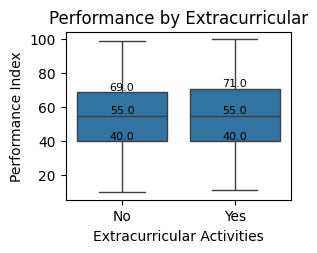

In [13]:
plt.subplot(2, 2, 3)

ax = sns.boxplot(
    data=train,
    x='Extracurricular Activities',
    y='Performance Index'
)

plt.title('Performance by Extracurricular')

# 그룹별 분위수 계산
quartiles = train.groupby('Extracurricular Activities')['Performance Index'].quantile([0.25, 0.5, 0.75]).unstack()

# 그래프에 숫자 표시
for i, category in enumerate(quartiles.index):
    q1 = quartiles.loc[category, 0.25]
    q2 = quartiles.loc[category, 0.50]
    q3 = quartiles.loc[category, 0.75]

    ax.text(i, q1, f'{q1:.1f}', ha='center', va='bottom', fontsize=8)
    ax.text(i, q2, f'{q2:.1f}', ha='center', va='bottom', fontsize=8)
    ax.text(i, q3, f'{q3:.1f}', ha='center', va='bottom', fontsize=8)

In [14]:
import pandas as pd

col = 'Performance Index'
group_col = 'Extracurricular Activities'

for name, group in train.groupby(group_col):
    
    q1 = group[col].quantile(0.25)
    q2 = group[col].quantile(0.50)   # median
    q3 = group[col].quantile(0.75)
    q4 = group[col].quantile(1.00)   # max
    
    iqr = q3 - q1
    
    whisker_low = group[col][group[col] >= q1 - 1.5 * iqr].min()
    whisker_high = group[col][group[col] <= q3 + 1.5 * iqr].max()
    
    print(f"\n[{name} 그룹]")
    print(f"Q1 (25%)           : {q1:.2f}")
    print(f"Q2 Median (50%)    : {q2:.2f}")
    print(f"Q3 (75%)           : {q3:.2f}")
    print(f"Q4 Max (100%)      : {q4:.2f}")
    print(f"Whisker Lower      : {whisker_low:.2f}")
    print(f"Whisker Upper      : {whisker_high:.2f}")


[No 그룹]
Q1 (25%)           : 40.00
Q2 Median (50%)    : 55.00
Q3 (75%)           : 69.00
Q4 Max (100%)      : 99.00
Whisker Lower      : 10.00
Whisker Upper      : 99.00

[Yes 그룹]
Q1 (25%)           : 40.00
Q2 Median (50%)    : 55.00
Q3 (75%)           : 71.00
Q4 Max (100%)      : 100.00
Whisker Lower      : 11.00
Whisker Upper      : 100.00


- 과외활동 참여자(Yes) 중앙값 71.0이 No(69.0) 보다 2점 높음

- **Yes 그룹 상위 25%(Q3:71.0)** 가 No(Q3:69.0)보다 우수, 최대값 100점 달성

- 분산 차이: Yes(11~100) vs No(10~99)로 Yes 그룹이 더 넓은 성적 범위 보유

- OneHotEncoding 적용: 중앙값 2점 차이로 예측력 향상 기대

### 5. 이전성적과 성적 간 관계 분석

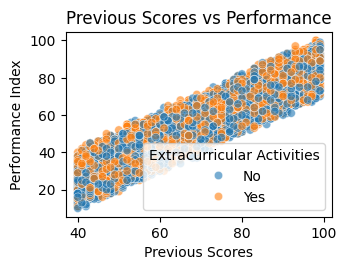

In [9]:
# Previous Scores vs Performance
plt.subplot(2, 2, 4)
sns.scatterplot(data=train, x='Previous Scores', y='Performance Index', hue='Extracurricular Activities', alpha=0.6)
plt.title('Previous Scores vs Performance')
plt.tight_layout()
plt.show()

- 선형 관계가 뚜렷함: Previous Scores 가 높으면 Performance 가 높다.

- **과외활동 Yes(주황)** 이 No(파랑)보다 상위 성적대에서 우세

- 외삽 위험 낮음: 40~100 범위 데이터로 모델 안정적 학습 예상

### 6. 이상치 및 왜도 분석

In [15]:
# IQR 이상치 분석 (결정용)
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    outlier_pct = len(outliers) / len(df) * 100
    return {
        'outliers_count': len(outliers),
        'outlier_pct': outlier_pct,
        'lower_bound': lower,
        'upper_bound': upper
    }

num_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

print("=== IQR 이상치 분석 결과 ===")
outlier_summary = {}
for col in num_cols:
    result = detect_outliers_iqr(train, col)
    outlier_summary[col] = result
    print(f"{col}:")
    print(f"  이상치 {result['outliers_count']}개 ({result['outlier_pct']:.1f}%)")
    print(f"  범위: [{result['lower_bound']:.1f}, {result['upper_bound']:.1f}]")
    print()

=== IQR 이상치 분석 결과 ===
Hours Studied:
  이상치 0개 (0.0%)
  범위: [-3.0, 13.0]

Previous Scores:
  이상치 0개 (0.0%)
  범위: [7.5, 131.5]

Sleep Hours:
  이상치 0개 (0.0%)
  범위: [0.5, 12.5]

Sample Question Papers Practiced:
  이상치 0개 (0.0%)
  범위: [-5.5, 14.5]



### 7. EDA 요약 및 전처리 전략

**요약**
1. Previous Scores 는 뚜렷한 선형 관계를 가짐 (r=0.91)

2. 과외활동 참여가 성적 향상 요인

3. 데이터 품질 우수: 결측치 없음, 왜도 낮음


**전처리 전략**

1. 범주형: OneHotEncoder (과외활동 Yes/No → 0/1 숫자로 변환)

2. 숫자형: StandardScaler (평균0, 분산1로 정규화)

3. 이상치: 없음 (IQR 기준 0%)

4. 자동화: ColumnTransformer (각 컬럼별 처리 자동화: 숫자형/범주형)

5. 모델: Ridge (LinearRegression + 과적합 방지)